# TakeMeter — Fine-Tuning Starter Notebook
### AI201 · Project 3

This notebook walks you through fine-tuning a text classifier on your annotated dataset and comparing it to a zero-shot baseline.

**What this notebook does for you (infrastructure):**
- Tokenizes your dataset and prepares it for training
- Runs the fine-tuning pipeline with DistilBERT
- Computes evaluation metrics and generates a confusion matrix
- Runs the Groq baseline and compares both models

**What you do (the actual work):**
- Collect and annotate your 200+ examples (done before opening this notebook)
- Define your label map and upload your CSV
- Write your Groq classification prompt using your label definitions
- Analyze the output and write your evaluation report

---
**Before you start:** Make sure you are using a T4 GPU runtime.  
Go to **Runtime → Change runtime type → T4 GPU**, then click Save.

In [1]:
# Install any dependencies not pre-installed on Colab
!pip install -q groq python-dotenv
print("✅ Dependencies ready")

✅ Dependencies ready


In [2]:
import pandas as pd
import numpy as np
import json
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset
import warnings
warnings.filterwarnings("ignore")

print("✅ Imports complete")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✅ Imports complete
PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


---
## Section 1: Load Your Dataset

Upload your labeled CSV and define your label map.  
Your CSV must have at least two columns: `text` (the post/comment) and `label` (your string label).

In [97]:
# ── TODO ──────────────────────────────────────────────────────────────────
# Define YOUR label map below.
# Keys are the string labels in your CSV; values are integers starting at 0.
# Add or remove entries to match your actual labels (2–4 labels supported).
#
# The example below is ILLUSTRATIVE ONLY (the r/nba taxonomy from the project
# page). DELETE it and use your own community's labels — submitting the
# example unchanged will not pass.
# ────────────────────────────────────────────────────────────────────────

LABEL_MAP = {
    "Opinion":  0,   # ← Replace with your first label
    "Fact":  1,   # ← Replace with your second label
    "Theory":  2,   # ← Replace with your third label (remove if you have 2 labels)
    "Hot_Take": 3,  # ← Uncomment if you have a fourth label
}

# ── END TODO ──────────────────────────────────────────────────────────────

ID_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_LABELS = len(LABEL_MAP)
print(f"Labels: {LABEL_MAP}")
print(f"Number of labels: {NUM_LABELS}")

Labels: {'Opinion': 0, 'Fact': 1, 'Theory': 2, 'Hot_Take': 3}
Number of labels: 4


In [108]:
# Upload your CSV from your computer
from google.colab import files
print("Select your labeled dataset CSV file...")
uploaded = files.upload()
CSV_PATH = list(uploaded.keys())[0]
print(f"Uploaded: {CSV_PATH}")

Select your labeled dataset CSV file...


Saving labeled_dataset_clean.csv to labeled_dataset_clean (5).csv
Uploaded: labeled_dataset_clean (5).csv


In [109]:
# Load and validate your dataset
df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()
df["label"] = df["label"].str.strip()

# ── TODO (if needed) ──────────────────────────────────────────────────────
# If your CSV uses different column names, rename them here.
# Example: df = df.rename(columns={"post": "text", "category": "label"})
# ── END TODO ──────────────────────────────────────────────────────────────

print(f"Columns: {df.columns.tolist()}")
print(f"Total examples: {len(df)}")
print()
print("Label distribution:")
print(df["label"].value_counts())

# Validate all labels are in LABEL_MAP
unknown = set(df["label"].unique()) - set(LABEL_MAP.keys())
if unknown:
    print(f"\n⚠️  Labels in CSV not found in LABEL_MAP: {unknown}")
    print("Update your LABEL_MAP above to include all labels.")
else:
    print("\n✅ All labels match your LABEL_MAP")

# Convert string labels to integers
df["label_id"] = df["label"].map(LABEL_MAP)
df = df.dropna(subset=["label_id"])
df["label_id"] = df["label_id"].astype(int)

Columns: ['text', 'label', 'notes']
Total examples: 211

Label distribution:
label
Fact        60
Opinion     51
Theory      50
Hot_Take    50
Name: count, dtype: int64

✅ All labels match your LABEL_MAP


---
## Section 2: Prepare Data for Training

Splits your dataset into train / validation / test sets and tokenizes the text.

In [110]:
# Train / val / test split — 70% / 15% / 15%
# Stratified so each split has roughly the same label distribution.
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["label_id"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["label_id"]
)

print(f"Train: {len(train_df)} examples")
print(f"Validation: {len(val_df)} examples")
print(f"Test: {len(test_df)} examples")
print()
print("Train label distribution:")
print(train_df["label"].value_counts())
print()
print("Test label distribution:")
print(test_df["label"].value_counts())

# Reset indices (needed for clean HuggingFace Dataset conversion)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

Train: 147 examples
Validation: 32 examples
Test: 32 examples

Train label distribution:
label
Fact        42
Hot_Take    35
Theory      35
Opinion     35
Name: count, dtype: int64

Test label distribution:
label
Fact        9
Theory      8
Opinion     8
Hot_Take    7
Name: count, dtype: int64


In [111]:
# Load tokenizer and tokenize all splits
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(examples):
    return tokenizer(examples["text"], truncation=True, max_length=256)

def make_dataset(df_split):
    ds = Dataset.from_pandas(
        df_split[["text", "label_id"]].rename(columns={"label_id": "labels"})
    )
    return ds.map(tokenize, batched=True)

train_dataset = make_dataset(train_df)
val_dataset   = make_dataset(val_df)
test_dataset  = make_dataset(test_df)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("✅ Tokenization complete")
print(f"Sample keys: {list(train_dataset[0].keys())}")

Map:   0%|          | 0/147 [00:00<?, ? examples/s]

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

✅ Tokenization complete
Sample keys: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']


---
## Section 3: Fine-Tune Your Model

Loads `distilbert-base-uncased` with a classification head and fine-tunes it on your training data.  
Training runs for 3 epochs and takes **5–15 minutes** on a T4 GPU.

> **Hyperparameter note:** The defaults below work well for datasets of 100–500 examples.  
> If you change any values, note what you changed and why in your README.

In [112]:
# Load DistilBERT with a classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID_TO_LABEL,
    label2id=LABEL_MAP,
)
print(f"✅ Model loaded: {MODEL_NAME}")
print(f"Output labels: {NUM_LABELS}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded: distilbert-base-uncased
Output labels: 4


In [113]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

In [114]:
# ── Hyperparameters ───────────────────────────────────────────────────────
# num_train_epochs  — passes through the training data; 3 is a good default
#                     for small datasets. Increase cautiously; more epochs
#                     risk overfitting on 200 examples.
# learning_rate     — 2e-5 is the standard starting point for fine-tuning
#                     BERT-family models. Lower → slower but more stable.
# per_device_train_batch_size — 16 fits T4 GPU comfortably.
#                     Reduce to 8 if you get out-of-memory errors.
# ─────────────────────────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir="./takemeter-model",
    num_train_epochs=6,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=10,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting fine-tuning... (5–15 minutes on T4 GPU)")
trainer.train()
print("\n✅ Fine-tuning complete")

Starting fine-tuning... (5–15 minutes on T4 GPU)


Epoch,Training Loss,Validation Loss,Accuracy
1,1.400056,1.383106,0.250000
2,1.391424,1.374266,0.250000
3,1.357819,1.357483,0.468750
4,1.322602,1.320119,0.562500
5,1.244040,1.227171,0.625000
6,1.096794,1.140295,0.718750


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Fine-tuning complete


---
## Section 4: Evaluate Fine-Tuned Model on Test Set

Runs inference on your locked test set and generates metrics and a confusion matrix.  
These numbers go directly into your evaluation report.

In [115]:
# Run inference on the test set
print("Running inference on test set...")
ft_output = trainer.predict(test_dataset)
ft_pred_ids = np.argmax(ft_output.predictions, axis=-1)
ft_true_ids = ft_output.label_ids

ft_probs = torch.nn.functional.softmax(
    torch.tensor(ft_output.predictions), dim=-1
).numpy()

# Overall accuracy
ft_accuracy = accuracy_score(ft_true_ids, ft_pred_ids)
print(f"\n🎯 Fine-tuned model accuracy: {ft_accuracy:.3f}")

# Per-class metrics
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("\nPer-class metrics (fine-tuned model):")
print(classification_report(ft_true_ids, ft_pred_ids, target_names=label_names, zero_division=0))

Running inference on test set...



🎯 Fine-tuned model accuracy: 0.625

Per-class metrics (fine-tuned model):
              precision    recall  f1-score   support

     Opinion       0.60      0.75      0.67         8
        Fact       0.78      0.78      0.78         9
      Theory       0.80      0.50      0.62         8
    Hot_Take       0.38      0.43      0.40         7

    accuracy                           0.62        32
   macro avg       0.64      0.61      0.61        32
weighted avg       0.65      0.62      0.63        32



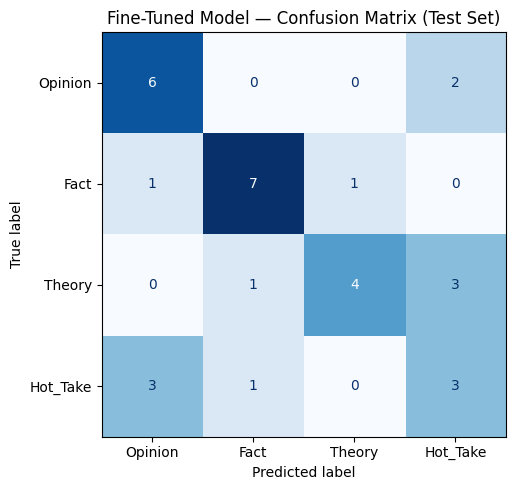

✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README


In [123]:
# Confusion matrix
cm = confusion_matrix(ft_true_ids, ft_pred_ids)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Fine-Tuned Model — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README")

In [117]:
# Print wrong predictions for your error analysis
# Review these carefully — pick 3 to analyze in depth in your README.

wrong_idx = np.where(ft_pred_ids != ft_true_ids)[0]
print(f"Wrong predictions: {len(wrong_idx)} / {len(ft_true_ids)}\n")

for i, idx in enumerate(wrong_idx[:15]):
    text = test_df.iloc[idx]["text"]
    true_label = ID_TO_LABEL[ft_true_ids[idx]]
    pred_label = ID_TO_LABEL[ft_pred_ids[idx]]
    confidence = ft_probs[idx][ft_pred_ids[idx]]
    print(f"--- #{i+1} ---")
    print(f"Text:      {text[:200]}{'...' if len(text) > 200 else ''}")
    print(f"True:      {true_label}")
    print(f"Predicted: {pred_label}  (confidence: {confidence:.2f})")
    print()

Wrong predictions: 12 / 32

--- #1 ---
Text:      Blackbeard's darkness fruit can nullify the regen of the holy knights and Gorosei
True:      Theory
Predicted: Fact  (confidence: 0.30)

--- #2 ---
Text:      Imo Ace was born to die. No deaths even to people like Pell from Alabasta. Makes it harder to believe when Ace goes down, waiting for the (ok but how he live).
True:      Opinion
Predicted: Hot_Take  (confidence: 0.34)

--- #3 ---
Text:      The actual One piece" is the tree or source of all devil fruits"
True:      Theory
Predicted: Hot_Take  (confidence: 0.30)

--- #4 ---
Text:      Pudding is gonna be used and forced to make someone forget about a major player in the race for one piece. A man dies when he is forgotten right? Teach is cooking up something hard.
True:      Theory
Predicted: Hot_Take  (confidence: 0.35)

--- #5 ---
Text:      Luffy won't see shanks untill he becomes king that way they won't have to fight shank would take a knee bow him head and luffy would put the

---
## Section 5: Baseline Classifier (Groq)

Runs your zero-shot baseline using `llama-3.3-70b-versatile`.  
You need to write the classification prompt using your label definitions.

In [86]:
from groq import Groq

# ── TODO: Add your Groq API key ───────────────────────────────────────────
# Recommended: use Colab Secrets so your key is never visible in the notebook.
#   1. Click the 🔑 icon in the left sidebar ("Secrets")
#   2. Add a secret named GROQ_API_KEY with your key as the value
#   3. Enable notebook access for the secret
#
# Then uncomment Option A below (and delete Option B).
#
# Option A — Colab Secrets (recommended):
from google.colab import userdata
# IMPORTANT: .strip() is added here to remove any accidental leading/trailing whitespace
# or newline characters that might be copied with the key from Colab Secrets.
GROQ_API_KEY = userdata.get("GROQ_API_KEY").strip()
#
# Option B — paste directly (do not commit to GitHub):
#GROQ_API_KEY = "your_groq_api_key_here"

assert GROQ_API_KEY, (
    "GROQ_API_KEY not set — add it in the Colab Secrets panel (🔑, left "
    "sidebar) and enable notebook access for this notebook, or use Option B above."
)

client = Groq(api_key=GROQ_API_KEY)
print("✅ Groq client initialized")
# Re-run the diagnostic cell `sPQFyr7-gykz` after this to confirm the fix.
# Then, re-run the model listing `0152e183`, and finally the baseline classification cells `c6fa8967` onwards.

✅ Groq client initialized


In [89]:
# ── TODO: Write your classification prompt ────────────────────────────────
# Your prompt should:
#   1. Name your community and task
#   2. Define each label in plain language (copy from your planning.md)
#   3. Give one example post per label
#   4. Tell the model to output ONLY the label name — nothing else
#
# The model's response must match one of your label strings exactly,
# or the classify_with_groq() function below will mark it as unparseable.
#
# ─────────────────────────────────────────────────────────────────────────
# REPLACE the placeholders below with your actual prompt. As written, this
# skeleton will NOT classify correctly — you must fill it in.

SYSTEM_PROMPT = """
You are classifying reddit discussions from One Piece.
Assign each post to exactly one of the following categories.

Opinion : Personal preference or subjective statement that most fans would consider reasonable.
Example: Honestly, Zoro is my favorite character from One Piece.

Fact : A true event that happened in the series.
Example: Whitebeard's last words were 'The one piece is real' and then he died standing.

Theory : Predictions and unconfirmed interesting ideas about future One Piece events.
Example: Imu did everything cause Nefertari d. Lili refused him and chose joyboy.

Hot_Take : A controversial opinion that many fans would strongly disagree with.
Example:  Haki ruined the fighting aspect of the series.

Respond with ONLY the label name.
Do not explain your reasoning.

Valid labels:
Opinion
Fact
Theory
Hot_Take
"""

print("Prompt length:", len(SYSTEM_PROMPT), "characters")

Prompt length: 836 characters


In [88]:
from google.colab import userdata

key = userdata.get("GROQ_API_KEY")

print("Key exists:", key is not None)
print("Length:", len(key))
print("Starts with gsk_:", key.strip().startswith("gsk_"))
print("Contains newline:", "\n" in key or "\r" in key)

Key exists: True
Length: 56
Starts with gsk_: True
Contains newline: False


In [22]:
from google.colab import userdata

key = userdata.get("GROQ_API_KEY")

print("Contains newline:", "\n" in key or "\r" in key)

Contains newline: False


In [42]:
try:
    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {"role": "user", "content": "Reply with only: Opinion"}
        ],
        temperature=0,
        max_tokens=10,
    )

    print("SUCCESS:", response.choices[0].message.content)

except Exception as e:
    print("ERROR:", repr(e))

SUCCESS: Opinion


### Diagnostic Steps for `APIConnectionError`

Let's run some checks to understand why the `APIConnectionError` is occurring. This error typically means the client cannot establish a network connection to the server.

1.  **Check general internet connectivity:** Ensure your Colab runtime has outbound internet access.
2.  **Check Groq API endpoint connectivity:** Specifically try to reach the Groq API server.
3.  **Verify model name:** Confirm the model `llama-3.3-70b-versatile` is currently available and correctly named.

In [43]:
# 1. Check general internet connectivity
print("--- Testing general internet connectivity (ping google.com) ---")
!ping -c 4 google.com

print("\n--- Testing general internet connectivity (curl example.com) ---")
!curl -v example.com

--- Testing general internet connectivity (ping google.com) ---
/bin/bash: line 1: ping: command not found

--- Testing general internet connectivity (curl example.com) ---
*   Trying 104.20.23.154:80...
* Connected to example.com (104.20.23.154) port 80 (#0)
> GET / HTTP/1.1
> Host: example.com
> User-Agent: curl/7.81.0
> Accept: */*
> 
* Mark bundle as not supporting multiuse
< HTTP/1.1 200 OK
< Date: Tue, 23 Jun 2026 07:27:18 GMT
< Content-Type: text/html
< Transfer-Encoding: chunked
< Connection: keep-alive
< Server: cloudflare
< Last-Modified: Fri, 19 Jun 2026 18:46:03 GMT
< Allow: GET, HEAD
< Accept-Ranges: bytes
< Age: 13853
< cf-cache-status: HIT
< CF-RAY: a101c4fd8e1e3e3e-SIN
< 
<!doctype html><html lang="en"><head><title>Example Domain</title><link rel="icon" href="data:,"><meta name="viewport" content="width=device-width, initial-scale=1"><style>body{background:#eee;width:60vw;margin:15vh auto;font-family:system-ui,sans-serif}h1{font-size:1.5em}div{opacity:0.8}a:link,a:visit

In [26]:
# 2. Check Groq API endpoint connectivity
# This attempts to connect to the Groq API endpoint to see if there are any network issues.
# It won't make a valid API request but will show connection details.
print("\n--- Testing connectivity to Groq API endpoint ---")
!curl -v https://api.groq.com/openai/v1/chat/completions


--- Testing connectivity to Groq API endpoint ---
*   Trying 172.64.149.20:443...
* Connected to api.groq.com (172.64.149.20) port 443 (#0)
* ALPN, offering h2
* ALPN, offering http/1.1
*  CAfile: /etc/ssl/certs/ca-certificates.crt
*  CApath: /etc/ssl/certs
* TLSv1.0 (OUT), TLS header, Certificate Status (22):
* TLSv1.3 (OUT), TLS handshake, Client hello (1):
* TLSv1.2 (IN), TLS header, Certificate Status (22):
* TLSv1.3 (IN), TLS handshake, Server hello (2):
* TLSv1.2 (IN), TLS header, Finished (20):
* TLSv1.2 (IN), TLS header, Supplemental data (23):
* TLSv1.3 (IN), TLS handshake, Encrypted Extensions (8):
* TLSv1.3 (IN), TLS handshake, Certificate (11):
* TLSv1.3 (IN), TLS handshake, CERT verify (15):
* TLSv1.3 (IN), TLS handshake, Finished (20):
* TLSv1.2 (OUT), TLS header, Finished (20):
* TLSv1.3 (OUT), TLS change cipher, Change cipher spec (1):
* TLSv1.2 (OUT), TLS header, Supplemental data (23):
* TLSv1.3 (OUT), TLS handshake, Finished (20):
* SSL connection using TLSv1.3 / TL

In [118]:
# 3. List available Groq models to verify the model name
# This will help confirm if 'llama-3.3-70b-versatile' is a valid and available model.
# If you can't even connect to list models, it points to a deeper network issue.

print("\n--- Listing available Groq models ---")
try:
    models = client.models.list()
    for model_obj in models.data:
        print(model_obj.id)
except Exception as e:
    print(f"Error listing models: {e}")


--- Listing available Groq models ---
whisper-large-v3-turbo
openai/gpt-oss-20b
qwen/qwen3.6-27b
groq/compound-mini
allam-2-7b
whisper-large-v3
canopylabs/orpheus-arabic-saudi
meta-llama/llama-prompt-guard-2-86m
meta-llama/llama-prompt-guard-2-22m
canopylabs/orpheus-v1-english
groq/compound
llama-3.3-70b-versatile
llama-3.1-8b-instant
meta-llama/llama-4-scout-17b-16e-instruct
qwen/qwen3-32b
openai/gpt-oss-safeguard-20b
openai/gpt-oss-120b


After running the above cells, analyze their output:

*   If `ping` and `curl example.com` fail, it indicates a general network issue with your Colab runtime. This is rare, but can happen.
*   If `ping` and `curl example.com` succeed, but `curl https://api.groq.com/...` fails, there might be a specific routing or firewall issue blocking access to Groq's servers from your Colab region, or a temporary outage on Groq's side.
*   If `curl https://api.groq.com/...` shows a successful connection (e.g., HTTP 401 Unauthorized because no API key is passed, but the connection itself works), and listing models also fails, then the issue might be specific to the `chat.completions.create` call, possibly due to an incorrect model name or parameters, or an issue with your `client` object despite initialization success.

Based on these results, we can narrow down the problem.

In [119]:
def classify_with_groq(text):
    """Classify a single post. Returns a label string or None if unparseable."""
    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": f"Classify this post:\n\n{text}"},
            ],
            temperature=0,
            max_tokens=20,
        )
        raw = response.choices[0].message.content.strip().lower()
        raw = raw.replace("opinon", "opinion")
        # Match the model's output to a label. Check longest labels first so a
        # label that is a substring of another (e.g. "recommendation" vs.
        # "strong_recommendation") can't be matched by mistake.
        for label in sorted(LABEL_MAP, key=len, reverse=True):
            if raw == label.lower() or label.lower() in raw:
                return label
        # If no match is found, print the raw output for debugging
        print(f"⚠️  Could not parse model output: '{raw}' for text: '{text[:50]}...' ")
        return None  # model output didn't match any known label
    except Exception as e:
        print(f"API error: {e}")
        return None


# Run baseline on test set
print(f"Running baseline on {len(test_df)} examples...")
print("(May take a few minutes — 0.1s delay between requests to respect free-tier limits)\n")

baseline_preds = []
for i, (_, row) in enumerate(test_df.iterrows()):
    pred = classify_with_groq(row["text"])
    baseline_preds.append(pred)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(test_df)} complete...")
    time.sleep(0.1)

none_count = baseline_preds.count(None)
if none_count > 0:
    print(f"\n⚠️  {none_count} responses could not be parsed.")
    print("Review your prompt — the model may not be outputting clean label names.")

Running baseline on 32 examples...
(May take a few minutes — 0.1s delay between requests to respect free-tier limits)

  10/32 complete...
  20/32 complete...
  30/32 complete...


In [120]:
# Baseline metrics (exclude unparseable responses)
valid = [(p, t) for p, t in zip(baseline_preds, test_df["label_id"])
         if p is not None]
bl_pred_ids = [LABEL_MAP[p] for p, _ in valid]
bl_true_ids = [t for _, t in valid]

bl_accuracy = accuracy_score(bl_true_ids, bl_pred_ids)
print(f"🎯 Baseline accuracy: {bl_accuracy:.3f}  "
      f"(evaluated on {len(valid)}/{len(test_df)} parseable responses)")
print()
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("Per-class metrics (baseline):")
print(classification_report(bl_true_ids, bl_pred_ids, target_names=label_names, zero_division=0))

🎯 Baseline accuracy: 0.875  (evaluated on 32/32 parseable responses)

Per-class metrics (baseline):
              precision    recall  f1-score   support

     Opinion       0.70      0.88      0.78         8
        Fact       1.00      0.89      0.94         9
      Theory       0.89      1.00      0.94         8
    Hot_Take       1.00      0.71      0.83         7

    accuracy                           0.88        32
   macro avg       0.90      0.87      0.87        32
weighted avg       0.90      0.88      0.88        32



---
## Section 6: Compare Results and Export

Side-by-side comparison of both models.  
Download the output files and commit them to your GitHub repo.

In [121]:
print("=" * 50)
print("RESULTS COMPARISON")
print("=" * 50)
print(f"{'Model':<35} {'Accuracy':>8}")
print("-" * 45)
print(f"{'Zero-shot baseline (Groq)':<35} {bl_accuracy:>8.3f}")
print(f"{'Fine-tuned DistilBERT':<35} {ft_accuracy:>8.3f}")
print("-" * 45)
delta = ft_accuracy - bl_accuracy
direction = "improvement" if delta >= 0 else "regression"
print(f"\nFine-tuning {direction}: {abs(delta):.3f}")
print()
print("Use these numbers in your README evaluation report.")

RESULTS COMPARISON
Model                               Accuracy
---------------------------------------------
Zero-shot baseline (Groq)              0.875
Fine-tuned DistilBERT                  0.625
---------------------------------------------

Fine-tuning regression: 0.250

Use these numbers in your README evaluation report.


In [122]:
# Save results JSON — commit to your GitHub repo and reference in README
results = {
    "baseline_accuracy": round(bl_accuracy, 4),
    "finetuned_accuracy": round(ft_accuracy, 4),
    "improvement": round(ft_accuracy - bl_accuracy, 4),
    "test_set_size": len(test_df),
    "label_map": LABEL_MAP,
    "model": MODEL_NAME,
}
with open("evaluation_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("✅ Files ready to download:")
print("   evaluation_results.json  — metrics for your README")
print("   confusion_matrix.png     — include in your README")
print()
print("Download via: Files panel (📁) on the left → right-click → Download")

✅ Files ready to download:
   evaluation_results.json  — metrics for your README
   confusion_matrix.png     — include in your README

Download via: Files panel (📁) on the left → right-click → Download
